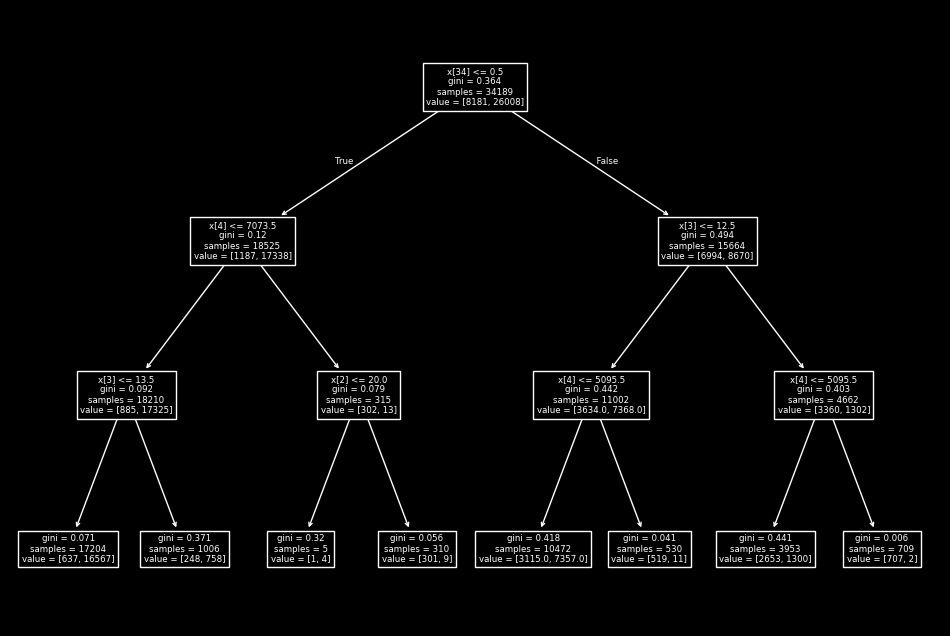

[Text(0.5, 0.875, 'marital_status_Married-civ-spouse <= 0.5\nsamples = 100.0%\nvalue = [0.239, 0.761]\nclass = low'),
 Text(0.25, 0.625, 'capital_gain <= 7073.5\n54.2%\n[0.064, 0.936]\nlow'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'education_num <= 13.5\n53.3%\n[0.049, 0.951]\nlow'),
 Text(0.0625, 0.125, '50.3%\n[0.037, 0.963]\nlow'),
 Text(0.1875, 0.125, '2.9%\n[0.247, 0.753]\nlow'),
 Text(0.375, 0.375, 'age <= 20.0\n0.9%\n[0.959, 0.041]\nhigh'),
 Text(0.3125, 0.125, '0.0%\n[0.2, 0.8]\nlow'),
 Text(0.4375, 0.125, '0.9%\n[0.971, 0.029]\nhigh'),
 Text(0.75, 0.625, 'education_num <= 12.5\n45.8%\n[0.447, 0.553]\nlow'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'capital_gain <= 5095.5\n32.2%\n[0.33, 0.67]\nlow'),
 Text(0.5625, 0.125, '30.6%\n[0.297, 0.703]\nlow'),
 Text(0.6875, 0.125, '1.6%\n[0.979, 0.021]\nhigh'),
 Text(0.875, 0.375, 'capital_gain <= 5095.5\n13.6%\n[0.721, 0.279]\nhigh'),
 Text(0.8125, 0.125, '11.6%\n[0.671, 0.329]\nhigh'),
 Text(0.9375, 0.125, '2.1%\n

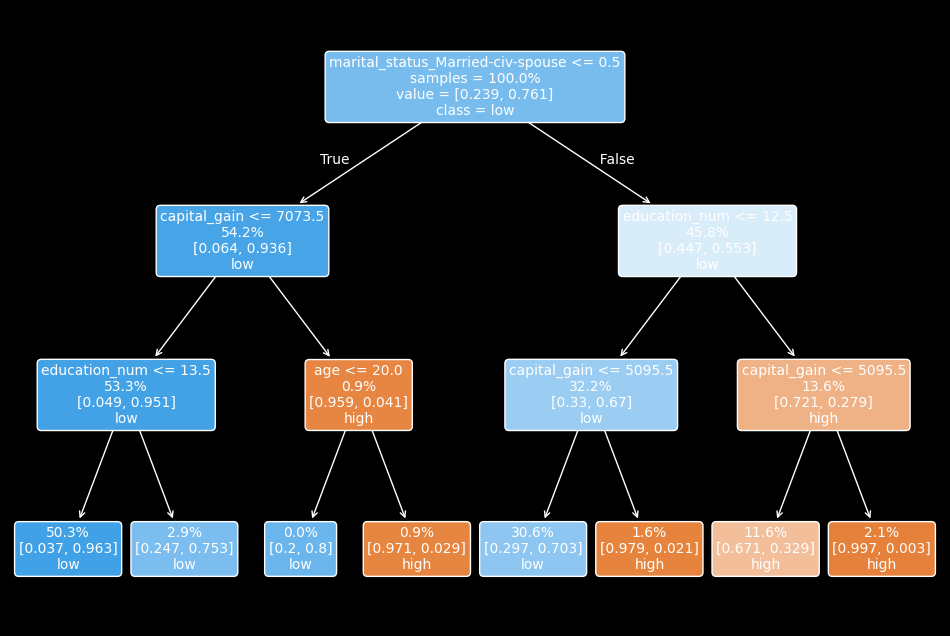

In [3]:
import pandas as pd

df_train = pd.read_csv('data/df_train_02.csv')
df_test = pd.read_csv('data/df_test_02.csv')

# 3. 의사결정나무 모델 만들기
# 전처리가 끝났으니 모델을 만드는 작업
# 모델을 만들때는 df_train을 사용하고, 모델이 만들어 진 후 모델을 평가할 때 df_test을 사용

# 01. 모델 설정하기
# 의사결정나무 모델을 만들 대 sklearn의 DecisionTreeClassifier 클래스를 사용

# DecisionTreeClassifier의 파라미터

# random_state : 난수 초기값. 변수 선택 과정에서 난수를 이용하기 때문에 코드를 실행할 때마다
# 결과가 조금씩 달라짐
# 난수를 고정하면 코드를 여러번 실행해도 결과가 항상 같음

# max_depth : 나무의 길이 노드를 최대 몇 번까지 분할할지 정함
# 숫자가 클수록 노드를 여러 번 분할해 복잡한 모델을 만듬
# 값을 지정하지 않으면 노드를 최대한 많이 분할. 단순한 모델을 만들기 위해 3을 입력.

from sklearn import tree
clf = tree.DecisionTreeClassifier(random_state=1234, # 난수 생성
                                  max_depth=3)

# 02. 모델 만들기
# df_train에서 예측 변수와 타겟 변수를 각각 추출해 데이터 프레임을 만듬
# clf.fit()의 X에는 예측 변수, y에는 타겟 변수를 입력
train_x = df_train.drop(columns='income') # 예측 변수 추출
train_y = df_train['income'] # 타겟 변수 추출

model = clf.fit(X=train_x, y=train_y) # 모델 만들기

# 3. 모델 구조 살펴보기
# 완성된 모델을 그래프로 만들어 구조를 살펴봄
# tree.plot_tree()을 이용하면 모델을 시각화할 수 있음

import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize':[12, 8], # 그래프 크기 설정
                     'figure.dpi': '100'}) # 해상도 설정

tree.plot_tree(model)
plt.show()

# tree.plot_tree()에 몇 가지 파라미터를 추가해 그래프를 보기 좋게 수정
tree.plot_tree(model,
               feature_names=train_x.columns, # 예측 변수명
               class_names=['high', 'low'], # 파겟 변수 클래스, 알파벳 순
               proportion=True, # 비율 표기
               filled=True, # 색칠
               rounded=True, # 둥근테두리
               impurity=False, # 불순도 표시
               label = 'root', # label 표시 위치
               fontsize = 10 # 글자 크기
               )

In [5]:
# 01. 노드의 값
# 1) 첫번째 노드
# martial_status_Married-div-spouse <= 0.5
# samples 100.0%
# value = [0.239, 0.761]
# class = low


In [ ]:
# samples = 100.0% : 노드에 해당하는 관측치 비율
# 전체 데이터의 몇 퍼센트가 해당 노드에 분류됬는지 나타냄
# 첫 번째 노드는 아직 한 번도 나뉘지 않았으므로 데이터의 100%가 이 노드에 속함
# 다음 단계의 노드로 내려가면 데이터가 여러 노드로 분리되므로 비율이 줄어듬
# 예를 들어 두 번째 노드를 보면 왼쪽 노드는 54.2%, 오른쪽 노드는 45.8%여서 같은 단계의 노드 비율을 모두 더하면 100%

# value = [0.239, 0.761] : 타겟 변수의 클래스별 비율
# 타겟 변수의 클래스별 비율을 알파벳 순으로 나타남
# 타겟 변수 income의 'high', 'low' 중 'high'가 알파벳순으로 우선하므로
# 'high', 'low' 순으로 비율이 표시
# 값을 보면 전체 데이터 중 'high'가 23.9%, 'low'가 76.1%라는 것을 알 수 있음

# class = low : 우세한 클래스 : 0.5 기준
# 0.5를 기준으로 타겟 변수의 두 클래스 중 어느쪽이 더 많은지 나타냄
# 'high'가 23.9%, 'low'가 76.1%

# martial_status 결혼 상태
# martial_status_Married-civ-spouse <= 0.5 : 분리 기준
# 노드를 분리할 때 사용할 기준을 나타냄
# 이 기준을 충족하는 데이터는 왼쪽, 충족하지 않은 데이터는 오른쪽 노드로 할당
# martial_status_Married_civ-spouse는 원핫 인코딩으로 만들어진 변수로 기혼이면 1, 비혼이면 0으로 되어 있음
# 따라서 비혼이면 변수의 값이 0이므로
# 'martial_status_Married-civ-spouse <= 0.5(비혼)' 조건을 충족해 왼쪽 노드로 내려가고,
# 기혼이면 조건을 충족하지 않으므로 오른쪽으로 내려감
# 즉, 비혼은 왼쪽 노드, 기혼은 오른쪽 노드로 내려감
# 다른 노드도 분리 기준이 표시되지만 마지막 단계의 '끝 노드'는 더이상 나뉘지 않으므로 분리 기준이 표시되지 않음


# 2) 왼쪽 노드
# 첫번째 노드의 조건 'martial_status_Married-civ-spouse <= 0.5(비혼)'을 충족한 비혼자가 이 노드에 할당
# capital_gain 자본 소득(USD)
# capital_gain <= 7073.5
# 54.2%
# [0.064, 0.936]
# low
# 비혼자는 전체의 54.2%
# 비혼자의 income은 'high' 6.4%, 'low' 93.6%로 'low'가 더 많음
# 다음으로 노드를 나누는 기준은 'capital_gain <= 7073.5'

# 3) 오른쪽 노드
# 첫 번째 노드의 조건 'martial_status_Married-civ-spouse <= 0.5(비혼)'을 충족하지 않은 기혼자가 이 노드에 할당
# education_num <= 12.5
# 45.8%
# [0.447, 0.553]
# low
# 기혼자는 전체의 45.8%
# 기혼자의 income은 'high' 44.7%, 'low' 55.3%로 'low'가 더 많음
# 다음으로 노드를 나누는 기준은 'education_num <= 12.5'

